In [1]:

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import Point
from geopy.distance import geodesic
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [2]:
df = pd.read_csv('yellow_tripdata_2016-01.csv')

In [3]:
def create_rotated_grid(polygon, rows, cols):
    """
    Create a rows x cols grid inside the quadrilateral defined by `polygon`.
    polygon: np.array of shape (4, 2) with coordinates [top-left, top-right, bottom-right, bottom-left]
    Returns: grid of shape (rows, cols, 2) with lat/lon coordinates
    """
    top_edge = np.linspace(polygon[0], polygon[1], cols)
    bottom_edge = np.linspace(polygon[3], polygon[2], cols)
    
    grid = np.zeros((rows, cols, 2))
    for i in range(cols):
        grid[:, i] = np.linspace(top_edge[i], bottom_edge[i], rows)
    
    return grid

def point_in_polygon(point, polygon):
    """Check if a point is inside a polygon using ray casting algorithm"""
    x, y = point
    n = len(polygon)
    inside = False
    
    p1x, p1y = polygon[0]
    for i in range(1, n + 1):
        p2x, p2y = polygon[i % n]
        if y > min(p1y, p2y):
            if y <= max(p1y, p2y):
                if x <= max(p1x, p2x):
                    if p1y != p2y:
                        xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                    if p1x == p2x or x <= xinters:
                        inside = not inside
        p1x, p1y = p2x, p2y
    
    return inside

# Define your rectangle coordinates (lon, lat)
p1 = (-73.965, 40.815)  # Top-left
p2 = (-73.930, 40.800)  # Top-right  
p3 = (-73.975, 40.740)  # Bottom-right
p4 = (-74.008, 40.754)  # Bottom-left

polygon = np.array([p1, p2, p3, p4])

# Create 15x15 grid aligned with your rectangle
grid = create_rotated_grid(polygon, rows=15, cols=15)

print("Grid shape:", grid.shape)
print("Grid bounds:")
print(f"Longitude range: {grid[:,:,0].min():.6f} to {grid[:,:,0].max():.6f}")
print(f"Latitude range: {grid[:,:,1].min():.6f} to {grid[:,:,1].max():.6f}")

Grid shape: (15, 15, 2)
Grid bounds:
Longitude range: -74.008000 to -73.930000
Latitude range: 40.740000 to 40.815000


In [4]:
# Filter data for rides within your polygon and time window
df['time'] = pd.to_datetime(df['tpep_pickup_datetime'])

# First filter by time (January 2nd, 2016, 9 AM hour)
df_time_filtered = df[(df['time'].dt.date == pd.to_datetime('2016-01-02').date()) &
                      (df['time'].dt.hour == 9) &
                      (df['time'].dt.minute >= 0) &
                      (df['time'].dt.minute < 60)]

# Then filter by polygon bounds for both pickup and dropoff
df_filtered = []
for index, row in df_time_filtered.iterrows():
    pickup_point = (row['pickup_longitude'], row['pickup_latitude'])
    dropoff_point = (row['dropoff_longitude'], row['dropoff_latitude'])
    
    if (point_in_polygon(pickup_point, polygon) and 
        point_in_polygon(dropoff_point, polygon)):
        df_filtered.append(row)

df_filtered = pd.DataFrame(df_filtered)

print(f"Rides on Jan 2nd 2016 between 9-10 AM within polygon: {len(df_filtered)}")
if len(df_filtered) > 0:
    print(df_filtered[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'time']].head())

Rides on Jan 2nd 2016 between 9-10 AM within polygon: 3975
        pickup_latitude  pickup_longitude  dropoff_latitude  \
129104        40.793442        -73.951736         40.762699   
129105        40.759762        -73.974144         40.779533   
129106        40.752354        -73.978310         40.760704   
129107        40.752262        -73.993423         40.746826   
129108        40.776791        -73.955544         40.771511   

        dropoff_longitude                time  
129104         -73.986320 2016-01-02 09:00:00  
129105         -73.961838 2016-01-02 09:00:00  
129106         -73.998009 2016-01-02 09:00:01  
129107         -73.983948 2016-01-02 09:00:01  
129108         -73.961372 2016-01-02 09:00:01  


In [5]:
# Get OSMnx graph for the polygon area
min_lat = polygon[:, 1].min()
max_lat = polygon[:, 1].max()
min_lon = polygon[:, 0].min()
max_lon = polygon[:, 0].max()

# Add some padding for the graph
padding = 0.005
graph = ox.graph_from_bbox(
    bbox=(min_lon - padding, min_lat - padding, max_lon + padding, max_lat + padding),
    network_type='drive'
)

In [6]:
def assign_to_grid_cell(point_lon, point_lat, grid):
    """
    Find the closest grid cell for a given point
    Returns (row, col) indices
    """
    min_dist = float('inf')
    best_row, best_col = -1, -1
    
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            cell_lon, cell_lat = grid[i, j]
            dist = geodesic((point_lat, point_lon), (cell_lat, cell_lon)).meters
            if dist < min_dist:
                min_dist = dist
                best_row, best_col = i, j
    
    return best_row, best_col

# Process rides and assign to grid cells
grid_rides = []

for idx, ride in df_filtered.iterrows():
    pickup_row, pickup_col = assign_to_grid_cell(
        ride['pickup_longitude'], 
        ride['pickup_latitude'],
        grid
    )
    
    dropoff_row, dropoff_col = assign_to_grid_cell(
        ride['dropoff_longitude'], 
        ride['dropoff_latitude'],
        grid
    )
    
    # Skip if same cell
    if (pickup_row, pickup_col) == (dropoff_row, dropoff_col):
        continue
    
    # Calculate distance between grid cells
    pickup_coords = grid[pickup_row, pickup_col]
    dropoff_coords = grid[dropoff_row, dropoff_col]
    distance_km = geodesic(
        (pickup_coords[1], pickup_coords[0]),
        (dropoff_coords[1], dropoff_coords[0])
    ).kilometers
    
    grid_rides.append({
        'pickup_cell_row': pickup_row,
        'pickup_cell_col': pickup_col,
        'dropoff_cell_row': dropoff_row,
        'dropoff_cell_col': dropoff_col,
        'distance_km': distance_km,
        'original_index': idx
    })

grid_rides_df = pd.DataFrame(grid_rides)
print(f"Processed {len(grid_rides_df)} rides in rotated grid format")

Processed 3928 rides in rotated grid format


In [7]:
def create_enhanced_map_with_grid_cells():
    center_lat = polygon[:, 1].mean()
    center_lon = polygon[:, 0].mean()
    my_map = folium.Map(location=[center_lat, center_lon], zoom_start=14)

    # Add the polygon boundary
    polygon_coords = [(lat, lon) for lon, lat in polygon]
    polygon_coords.append(polygon_coords[0])  # Close the polygon
    folium.Polygon(
        locations=polygon_coords,
        color='red',
        weight=3,
        fill=False,
        popup="Study Area Boundary"
    ).add_to(my_map)

    # Create proper grid cells as rectangles
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            # Get the four corners of each grid cell
            corners = []
            
            # Current cell center
            center = grid[i, j]
            
            # Calculate cell boundaries by interpolating between adjacent cells
            if i == 0 and j == 0:  # Top-left corner
                # Use differences to adjacent cells to estimate size
                right_diff = grid[i, j+1] - center if j < grid.shape[1]-1 else (0, 0)
                down_diff = grid[i+1, j] - center if i < grid.shape[0]-1 else (0, 0)
                half_right = right_diff * 0.5
                half_down = down_diff * 0.5
            elif i == 0 and j == grid.shape[1]-1:  # Top-right corner
                left_diff = center - grid[i, j-1]
                down_diff = grid[i+1, j] - center if i < grid.shape[0]-1 else (0, 0)
                half_right = left_diff * 0.5
                half_down = down_diff * 0.5
            elif i == grid.shape[0]-1 and j == 0:  # Bottom-left corner
                right_diff = grid[i, j+1] - center if j < grid.shape[1]-1 else (0, 0)
                up_diff = center - grid[i-1, j]
                half_right = right_diff * 0.5
                half_down = up_diff * 0.5
            elif i == grid.shape[0]-1 and j == grid.shape[1]-1:  # Bottom-right corner
                left_diff = center - grid[i, j-1]
                up_diff = center - grid[i-1, j]
                half_right = left_diff * 0.5
                half_down = up_diff * 0.5
            else:
                # Interior cells - use average of adjacent cells
                if j < grid.shape[1]-1:
                    right_diff = grid[i, j+1] - center
                else:
                    right_diff = center - grid[i, j-1]
                
                if i < grid.shape[0]-1:
                    down_diff = grid[i+1, j] - center
                else:
                    down_diff = center - grid[i-1, j]
                
                half_right = right_diff * 0.5
                half_down = down_diff * 0.5
            
            # Calculate the four corners
            top_left = center - half_right - half_down
            top_right = center + half_right - half_down
            bottom_right = center + half_right + half_down
            bottom_left = center - half_right + half_down
            
            # Create cell boundaries (lat, lon format for folium)
            cell_bounds = [
                (top_left[1], top_left[0]),
                (top_right[1], top_right[0]),
                (bottom_right[1], bottom_right[0]),
                (bottom_left[1], bottom_left[0])
            ]
            
            # Add grid cell as polygon
            folium.Polygon(
                locations=cell_bounds,
                color='blue',
                weight=1,
                fill=True,
                fillColor='lightblue',
                fillOpacity=0.3,
                popup=f"Cell ({i},{j})"
            ).add_to(my_map)
            
            # Add cell center marker
            folium.CircleMarker(
                location=[center[1], center[0]],
                radius=3,
                popup=f"Cell ({i},{j})",
                color='darkblue',
                fill=True
            ).add_to(my_map)

    # Add sample rides
    sample_size = min(10, len(df_filtered))
    for idx, (_, ride) in enumerate(df_filtered.head(sample_size).iterrows()):
        # Pickup point
        folium.Marker(
            [ride['pickup_latitude'], ride['pickup_longitude']], 
            popup=f"Pickup {idx}",
            icon=folium.Icon(color='green', icon='play')
        ).add_to(my_map)
        
        # Dropoff point
        folium.Marker(
            [ride['dropoff_latitude'], ride['dropoff_longitude']], 
            popup=f"Dropoff {idx}",
            icon=folium.Icon(color='red', icon='stop')
        ).add_to(my_map)
        
        # Add line connecting pickup to dropoff
        folium.PolyLine(
            locations=[
                [ride['pickup_latitude'], ride['pickup_longitude']],
                [ride['dropoff_latitude'], ride['dropoff_longitude']]
            ],
            color='orange',
            weight=2,
            opacity=0.7
        ).add_to(my_map)

    return my_map

# Create and save the enhanced map
enhanced_map = create_enhanced_map_with_grid_cells()
enhanced_map.save('enhanced_grid_rides.html')
print("Enhanced map with proper grid cells saved as 'enhanced_grid_rides.html'")

Enhanced map with proper grid cells saved as 'enhanced_grid_rides.html'


In [ ]:
# Calculate distances and travel times between all grid cells
n_rows, n_cols = 15, 15
cell_distances = np.zeros((n_rows, n_cols, n_rows, n_cols))
cell_times = np.zeros((n_rows, n_cols, n_rows, n_cols))

print("Calculating distances and times between all grid cell pairs...")

# Find nearest nodes for each grid cell
cell_nodes = {}
for i in range(n_rows):
    for j in range(n_cols):
        cell_coords = grid[i, j]
        try:
            nearest_node = ox.distance.nearest_nodes(graph, X=cell_coords[0], Y=cell_coords[1])
            cell_nodes[(i, j)] = nearest_node
        except Exception as e:
            print(f"Warning: Could not find node for cell ({i},{j})")
            cell_nodes[(i, j)] = None

# Calculate distances and times
default_speed_kph = 25.0

for i1 in range(n_rows):
    for j1 in range(n_cols):
        source_node = cell_nodes.get((i1, j1))
        source_coords = grid[i1, j1]
        
        for i2 in range(n_rows):
            for j2 in range(n_cols):
                if (i1, j1) == (i2, j2):
                    cell_distances[i1, j1, i2, j2] = 0.0
                    cell_times[i1, j1, i2, j2] = 0.0
                    continue
                
                target_node = cell_nodes.get((i2, j2))
                target_coords = grid[i2, j2]
                
                # Try network distance first, fall back to geodesic
                if source_node is not None and target_node is not None:
                    try:
                        route_length = nx.shortest_path_length(
                            graph, 
                            source=source_node, 
                            target=target_node,
                            weight='length'
                        )
                        dist_km = route_length / 1000.0
                    except:
                        dist_km = geodesic(
                            (source_coords[1], source_coords[0]),
                            (target_coords[1], target_coords[0])
                        ).kilometers
                else:
                    dist_km = geodesic(
                        (source_coords[1], source_coords[0]),
                        (target_coords[1], target_coords[0])
                    ).kilometers
                
                cell_distances[i1, j1, i2, j2] = dist_km
                cell_times[i1, j1, i2, j2] = (dist_km / default_speed_kph) * 60  # minutes

# Create directional matrices
UP, DOWN, LEFT, RIGHT = 0, 1, 2, 3

directional_weight_matrix = np.zeros((n_rows, n_cols, 4))
directional_time_matrix = np.zeros((n_rows, n_cols, 4))

for i in range(n_rows):
    for j in range(n_cols):
        # UP
        if i > 0:
            directional_weight_matrix[i, j, UP] = cell_distances[i, j, i-1, j]
            directional_time_matrix[i, j, UP] = cell_times[i, j, i-1, j]
        else:
            directional_weight_matrix[i, j, UP] = float('inf')
            directional_time_matrix[i, j, UP] = float('inf')
        
        # DOWN
        if i < n_rows-1:
            directional_weight_matrix[i, j, DOWN] = cell_distances[i, j, i+1, j]
            directional_time_matrix[i, j, DOWN] = cell_times[i, j, i+1, j]
        else:
            directional_weight_matrix[i, j, DOWN] = float('inf')
            directional_time_matrix[i, j, DOWN] = float('inf')
        
        # LEFT
        if j > 0:
            directional_weight_matrix[i, j, LEFT] = cell_distances[i, j, i, j-1]
            directional_time_matrix[i, j, LEFT] = cell_times[i, j, i, j-1]
        else:
            directional_weight_matrix[i, j, LEFT] = float('inf')
            directional_time_matrix[i, j, LEFT] = float('inf')
        
        # RIGHT
        if j < n_cols-1:
            directional_weight_matrix[i, j, RIGHT] = cell_distances[i, j, i, j+1]
            directional_time_matrix[i, j, RIGHT] = cell_times[i, j, i, j+1]
        else:
            directional_weight_matrix[i, j, RIGHT] = float('inf')
            directional_time_matrix[i, j, RIGHT] = float('inf')

# Save matrices and data
np.save('rotated_grid_coordinates.npy', grid)
np.save('weight_matrix.npy', directional_weight_matrix)
np.save('time_weight_matrix.npy', directional_time_matrix)
grid_rides_df.to_csv('ny_rotated_grid_rides.csv', index=False)

print("All matrices and data saved successfully!")
print(f"Grid coordinates shape: {grid.shape}")
print(f"Weight matrix shape: {directional_weight_matrix.shape}")
print(f"Time matrix shape: {directional_time_matrix.shape}")
print(f"Rides data: {len(grid_rides_df)} rides")

Calculating distances and times between all grid cell pairs...
All matrices and data saved successfully!
Grid coordinates shape: (15, 15, 2)
Weight matrix shape: (15, 15, 4)
Time matrix shape: (15, 15, 4)
Rides data: 3928 rides


=== SAMPLING ALL RIDES ===

=== UNIFORM SAMPLING RESULTS ===
Requested rides: 150
Sampled rides: 150

DISTANCE STATISTICS:
  Mean distance: 3.376 km
  Median distance: 3.301 km
  Std distance: 1.889 km
  Distance range: 0.468 - 7.141 km

UNIQUE LOCATION STATISTICS:
  Unique pickup locations: 82
  Unique dropoff locations: 73
  Total unique locations: 119
  Pickup-only locations: 46
  Dropoff-only locations: 37
  Shared locations (both pickup & dropoff): 36

GRID COVERAGE STATISTICS:
  Pickup coverage: 36.4% of grid
  Dropoff coverage: 32.4% of grid
  Total coverage: 52.9% of grid

MANHATTAN DISTANCE STATISTICS:
  Mean Manhattan distance: 9.25 cells
  Median Manhattan distance: 10.00 cells
  Max Manhattan distance: 20 cells

LOCATION FREQUENCY STATISTICS:
  Most popular pickup location used: 9 times
  Most popular dropoff location used: 9 times
  Average pickup frequency: 1.83
  Average dropoff frequency: 2.05

=== SAMPLING SHORT RIDES (0.2-1.0 KM) ===
Filtered to 2625 rides within 1.0-

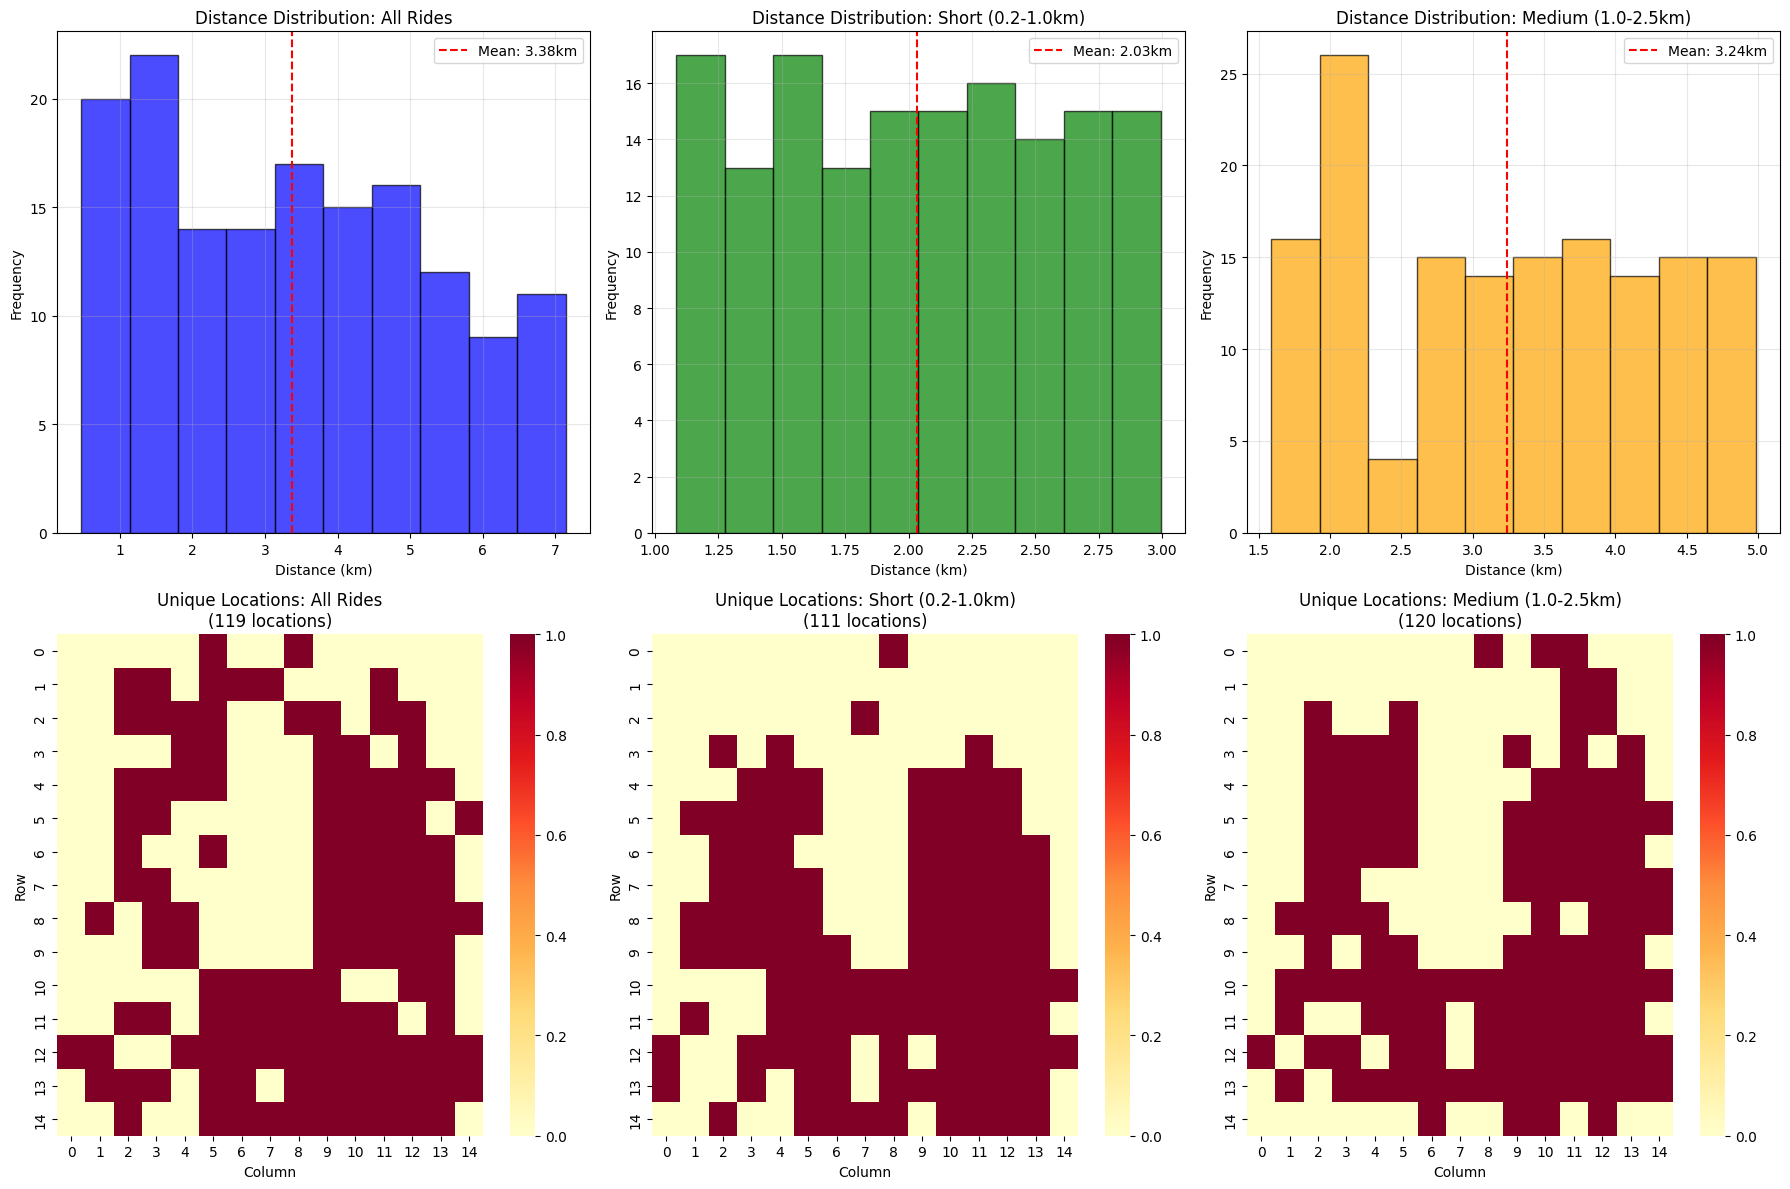


=== COMPARISON SUMMARY ===
Metric                    All Rides    Short Rides  Medium Rides
-----------------------------------------------------------------
Mean Distance (km)        3.376        2.033        3.237       
Unique Pickup Locs        82           80           80          
Unique Dropoff Locs       73           77           79          
Total Unique Locs         119          111          120         
Grid Coverage (%)         52.9         49.3         53.3        


In [9]:
def sample_fixed_positions_uniform(grid_rides_df, grid, num_agents=150, 
                                 distance_range=None, seed=42):
    """
    Sample rides with uniform distribution across distance bins
    
    Parameters:
    - grid_rides_df: DataFrame with ride data
    - grid: Grid coordinates array
    - num_agents: Number of rides to sample
    - distance_range: tuple (min_km, max_km) to filter rides (optional)
    - seed: Random seed for reproducibility
    """
    np.random.seed(seed)
    
    if len(grid_rides_df) == 0:
        print("No rides available for sampling")
        return [], []
    
    # Calculate distances for all rides if not already done
    if 'distance_km' not in grid_rides_df.columns:
        distances = []
        for _, row in grid_rides_df.iterrows():
            pickup_coords = grid[int(row['pickup_cell_row']), int(row['pickup_cell_col'])]
            dropoff_coords = grid[int(row['dropoff_cell_row']), int(row['dropoff_cell_col'])]
            dist = geodesic((pickup_coords[1], pickup_coords[0]), 
                          (dropoff_coords[1], dropoff_coords[0])).kilometers
            distances.append(dist)
        grid_rides_df['distance_km'] = distances
    
    # Filter by distance range if specified
    df_filtered = grid_rides_df.copy()
    if distance_range:
        min_dist, max_dist = distance_range
        df_filtered = df_filtered[(df_filtered['distance_km'] >= min_dist) & 
                                (df_filtered['distance_km'] <= max_dist)]
        print(f"Filtered to {len(df_filtered)} rides within {min_dist}-{max_dist} km range")
    
    if len(df_filtered) == 0:
        print("No rides available after filtering")
        return [], []
    
    # Uniform distribution across distance bins
    distances = df_filtered['distance_km'].values
    n_bins = min(10, len(df_filtered) // 5)  # Adaptive number of bins
    
    # Create distance bins
    bins = np.linspace(distances.min(), distances.max(), n_bins + 1)
    bin_indices = np.digitize(distances, bins) - 1
    
    # Sample uniformly from each bin
    samples_per_bin = num_agents // n_bins
    remaining = num_agents % n_bins
    
    selected_indices = []
    for bin_idx in range(n_bins):
        bin_mask = (bin_indices == bin_idx)
        bin_rides = df_filtered[bin_mask]
        
        if len(bin_rides) == 0:
            continue
            
        n_samples = samples_per_bin + (1 if bin_idx < remaining else 0)
        n_samples = min(n_samples, len(bin_rides))
        
        sampled = bin_rides.sample(n_samples, replace=True)
        selected_indices.extend(sampled.index.tolist())
    
    # Fill remaining if needed
    while len(selected_indices) < num_agents:
        additional = df_filtered.sample(1)
        selected_indices.extend(additional.index.tolist())
        
    samples = df_filtered.loc[selected_indices[:num_agents]]
    
    # Extract positions
    start_positions = []
    end_positions = []
    
    for _, row in samples.iterrows():
        start_positions.append((int(row['pickup_cell_row']), int(row['pickup_cell_col'])))
        end_positions.append((int(row['dropoff_cell_row']), int(row['dropoff_cell_col'])))
    
    # Calculate comprehensive statistics
    achieved_distances = samples['distance_km'].values
    
    # Unique pickup and dropoff statistics
    unique_pickups = set(start_positions)
    unique_dropoffs = set(end_positions)
    unique_total = unique_pickups.union(unique_dropoffs)
    
    # Grid coverage statistics
    pickup_coverage = len(unique_pickups) / (grid.shape[0] * grid.shape[1]) * 100
    dropoff_coverage = len(unique_dropoffs) / (grid.shape[0] * grid.shape[1]) * 100
    total_coverage = len(unique_total) / (grid.shape[0] * grid.shape[1]) * 100
    
    # Manhattan distance statistics
    manhattan_distances = []
    for start, end in zip(start_positions, end_positions):
        manhattan_dist = abs(start[0] - end[0]) + abs(start[1] - end[1])
        manhattan_distances.append(manhattan_dist)
    manhattan_distances = np.array(manhattan_distances)
    
    # Print detailed statistics
    print(f"\n=== UNIFORM SAMPLING RESULTS ===")
    print(f"Requested rides: {num_agents}")
    print(f"Sampled rides: {len(start_positions)}")
    print()
    
    print("DISTANCE STATISTICS:")
    print(f"  Mean distance: {achieved_distances.mean():.3f} km")
    print(f"  Median distance: {np.median(achieved_distances):.3f} km")
    print(f"  Std distance: {achieved_distances.std():.3f} km")
    print(f"  Distance range: {achieved_distances.min():.3f} - {achieved_distances.max():.3f} km")
    print()
    
    print("UNIQUE LOCATION STATISTICS:")
    print(f"  Unique pickup locations: {len(unique_pickups)}")
    print(f"  Unique dropoff locations: {len(unique_dropoffs)}")
    print(f"  Total unique locations: {len(unique_total)}")
    print(f"  Pickup-only locations: {len(unique_pickups - unique_dropoffs)}")
    print(f"  Dropoff-only locations: {len(unique_dropoffs - unique_pickups)}")
    print(f"  Shared locations (both pickup & dropoff): {len(unique_pickups.intersection(unique_dropoffs))}")
    print()
    
    print("GRID COVERAGE STATISTICS:")
    print(f"  Pickup coverage: {pickup_coverage:.1f}% of grid")
    print(f"  Dropoff coverage: {dropoff_coverage:.1f}% of grid")
    print(f"  Total coverage: {total_coverage:.1f}% of grid")
    print()
    
    print("MANHATTAN DISTANCE STATISTICS:")
    print(f"  Mean Manhattan distance: {manhattan_distances.mean():.2f} cells")
    print(f"  Median Manhattan distance: {np.median(manhattan_distances):.2f} cells")
    print(f"  Max Manhattan distance: {manhattan_distances.max()} cells")
    print()
    
    # Location frequency analysis
    pickup_freq = {}
    dropoff_freq = {}
    for pos in start_positions:
        pickup_freq[pos] = pickup_freq.get(pos, 0) + 1
    for pos in end_positions:
        dropoff_freq[pos] = dropoff_freq.get(pos, 0) + 1
    
    pickup_frequencies = list(pickup_freq.values())
    dropoff_frequencies = list(dropoff_freq.values())
    
    print("LOCATION FREQUENCY STATISTICS:")
    print(f"  Most popular pickup location used: {max(pickup_frequencies)} times")
    print(f"  Most popular dropoff location used: {max(dropoff_frequencies)} times")
    print(f"  Average pickup frequency: {np.mean(pickup_frequencies):.2f}")
    print(f"  Average dropoff frequency: {np.mean(dropoff_frequencies):.2f}")
    
    return start_positions, end_positions, samples

# Example usage with detailed statistics
if len(grid_rides_df) > 0:
    
    # Example 1: All available rides
    print("=== SAMPLING ALL RIDES ===")
    uniform_start_all, uniform_end_all, samples_all = sample_fixed_positions_uniform(
        grid_rides_df, grid, num_agents=150
    )
    
    # Example 2: Short rides (0.2 - 1.0 km)
    print("\n=== SAMPLING SHORT RIDES (0.2-1.0 KM) ===")
    uniform_start_short, uniform_end_short, samples_short = sample_fixed_positions_uniform(
        grid_rides_df, grid, num_agents=150, distance_range=(1.0, 3.0)
    )
    
    # Example 3: Medium rides (1.0 - 2.5 km)
    print("\n=== SAMPLING MEDIUM RIDES (1.0-2.5 KM) ===")
    uniform_start_medium, uniform_end_medium, samples_medium = sample_fixed_positions_uniform(
        grid_rides_df, grid, num_agents=150, distance_range=(1.5, 5.0)
    )
    
    # Save your preferred selection (choose one)
    selected_start, selected_end = uniform_start_medium, uniform_end_medium  # Using medium range
    
    np.save('fixed_positions.npy', selected_start)
    np.save('fixed_destinations.npy', selected_end)
    print(f"\nSaved {len(selected_start)} uniformly sampled positions and destinations")
    
    # Enhanced Visualization with unique location analysis
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    datasets = [
        ("All Rides", samples_all, uniform_start_all, uniform_end_all),
        ("Short (0.2-1.0km)", samples_short, uniform_start_short, uniform_end_short),
        ("Medium (1.0-2.5km)", samples_medium, uniform_start_medium, uniform_end_medium)
    ]
    
    for i, (name, samples, starts, ends) in enumerate(datasets):
        distances = samples['distance_km'].values
        
        # Distance histogram
        axes[0, i].hist(distances, bins=10, alpha=0.7, edgecolor='black', 
                       color=['blue', 'green', 'orange'][i])
        axes[0, i].axvline(distances.mean(), color='red', linestyle='--', 
                          label=f'Mean: {distances.mean():.2f}km')
        axes[0, i].set_title(f'Distance Distribution: {name}')
        axes[0, i].set_xlabel('Distance (km)')
        axes[0, i].set_ylabel('Frequency')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)
        
        # Unique locations heatmap
        location_counts = np.zeros((15, 15))
        unique_locs = set(starts + ends)
        for pos in unique_locs:
            location_counts[pos[0], pos[1]] = 1
        
        sns.heatmap(location_counts, annot=False, cmap="YlOrRd", 
                   cbar=True, ax=axes[1, i])
        axes[1, i].set_title(f'Unique Locations: {name}\n({len(unique_locs)} locations)')
        axes[1, i].set_xlabel('Column')
        axes[1, i].set_ylabel('Row')
    
    plt.tight_layout()
    plt.savefig('uniform_sampling_detailed.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary comparison table
    print("\n=== COMPARISON SUMMARY ===")
    print(f"{'Metric':<25} {'All Rides':<12} {'Short Rides':<12} {'Medium Rides':<12}")
    print("-" * 65)
    
    all_unique = set(uniform_start_all + uniform_end_all)
    short_unique = set(uniform_start_short + uniform_end_short)
    medium_unique = set(uniform_start_medium + uniform_end_medium)
    
    print(f"{'Mean Distance (km)':<25} {samples_all['distance_km'].mean():<12.3f} "
          f"{samples_short['distance_km'].mean():<12.3f} {samples_medium['distance_km'].mean():<12.3f}")
    print(f"{'Unique Pickup Locs':<25} {len(set(uniform_start_all)):<12} "
          f"{len(set(uniform_start_short)):<12} {len(set(uniform_start_medium)):<12}")
    print(f"{'Unique Dropoff Locs':<25} {len(set(uniform_end_all)):<12} "
          f"{len(set(uniform_end_short)):<12} {len(set(uniform_end_medium)):<12}")
    print(f"{'Total Unique Locs':<25} {len(all_unique):<12} "
          f"{len(short_unique):<12} {len(medium_unique):<12}")
    print(f"{'Grid Coverage (%)':<25} {len(all_unique)/225*100:<12.1f} "
          f"{len(short_unique)/225*100:<12.1f} {len(medium_unique)/225*100:<12.1f}")
    
else:
    print("No rides found in the dataset")